# Data Preprocessing — Credit Risk Prediction

This notebook prepares the cleaned dataset for modeling: splitting into train/CV/test sets, 
handling missing values and anomalies, engineering new features, and encoding data separately 
for tree-based and linear models.

**Core design principle:** the train/CV/test split happens *before* any statistic (median, 
percentile, scaler parameters) is computed. All such statistics are derived from `x_train` only, 
then applied unchanged to `x_cv`, `x_test`, and the external Kaggle test set. This prevents data 
leakage — without it, information from validation/test data would implicitly influence how the 
training data itself is transformed, producing overly optimistic performance estimates.

In [ ]:
# Import libraries for data handling, visualization, preprocessing, feature selection, and model persistence.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import mutual_info_classif
import joblib

In [ ]:
# Load the raw training data for preprocessing.
credit_data = pd.read_csv('../data/cs-training.csv')
# Preview the imported records.
credit_data.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


The first column (`Unnamed: 0`) is a redundant row index and will be dropped.

In [ ]:
# Remove the exported row index because it is not a predictive feature.
credit_data = credit_data.drop('Unnamed: 0', axis=1)
# Confirm the remaining columns and values.
credit_data.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
# Count duplicate observations before removing them.
credit_data.duplicated().sum().item()

609

Duplicates are removed **before** imputation, not after. If done in the reverse order, two 
genuinely different rows could become identical purely because both had a missing value filled 
with the same median — and would then be incorrectly flagged and dropped as duplicates.

609 duplicated rows are present in the raw data and will be removed to prevent the model from 
overweighting repeated patterns.

In [ ]:
# Remove duplicate rows before imputation to avoid creating false duplicates.
credit_data = credit_data.drop_duplicates()
# Verify that duplicate rows have been removed.
credit_data.duplicated().sum().item()

0

In [ ]:
# Reset the row index after dropping duplicates and remove the old index column.
credit_data = credit_data.reset_index()
credit_data = credit_data.drop('index', axis=1)
# Display the cleaned table.
credit_data

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149386,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149387,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149388,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149389,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


The index is reset after removing duplicates to keep it continuous.

In [ ]:
# Separate the target variable from the model input features.
y = credit_data['SeriousDlqin2yrs']
X = credit_data.drop('SeriousDlqin2yrs', axis=1)
# Preview the feature matrix.
X.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## Train / CV / Test Split

The dataset is split into training (60%), cross-validation (20%), and test (20%) sets **before** 
any preprocessing statistics are calculated — this is the key step that makes the rest of the 
pipeline leakage-free.

`stratify=y` is used in both splits to preserve the original class ratio (93.3% / 6.7%) across 
all three sets. Without it, random splitting could produce sets with a noticeably different 
proportion of defaults, especially given how few positive examples exist relative to the dataset size.

In [ ]:
# Create a stratified 60/40 split so the training set preserves the target ratio.
x_train, x_, y_train, y_ =  train_test_split(X, y, test_size=0.4, random_state=1, stratify=y)
# Split the temporary 40% portion evenly into cross-validation and test sets.
x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.5, random_state=1, stratify=y_)
# Remove temporary split variables after they are no longer needed.
del x_, y_

In [ ]:
# Make independent copies so later transformations do not affect source views.
x_train = x_train.copy()
x_cv = x_cv.copy()
x_test = x_test.copy()

In [ ]:
# Inspect missing values in the training features before imputation.
x_train.isnull().sum()

RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           17581
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       2337
dtype: int64

As established in the EDA, both `MonthlyIncome` and `NumberOfDependents` are skewed, so the 
median (computed on `x_train` only) is used for imputation rather than the mean.

In addition to filling missing values, a binary flag (`*_is_missing`) is created for each 
imputed column. The fact that a value was missing may itself carry signal — for example, 
borrowers who don't report income might systematically differ in default risk from those who do.

In [ ]:
# Compute imputation values from the training set only to prevent data leakage.
monthly_income_median = x_train['MonthlyIncome'].median()
num_dependents_median = x_train['NumberOfDependents'].median()

# Fill missing values in any dataset using the fixed training-set medians.
def fill_missings(df):
    # Preserve whether each value was missing before replacement.
    df['MonthlyIncome_is_missing'] = df['MonthlyIncome'].isna().astype(int)
    df['NumberOfDependents_is_missing'] = df['NumberOfDependents'].isna().astype(int)

    # Replace missing values with statistics learned from x_train.
    df['MonthlyIncome'] = df['MonthlyIncome'].fillna(monthly_income_median)
    df['NumberOfDependents'] = df['NumberOfDependents'].fillna(num_dependents_median)
    return df

In [ ]:
# Apply the same missing-value transformation to every data split.
x_train = fill_missings(x_train)
x_cv = fill_missings(x_cv)
x_test = fill_missings(x_test)
# Confirm that the training set contains no remaining missing values.
x_train.isnull().sum()

RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
MonthlyIncome_is_missing                0
NumberOfDependents_is_missing           0
dtype: int64

No missing values remain in `x_train` (and, by construction, in `x_cv`/`x_test`, since they use 
the same imputation values).

## Fixing Anomalous Values

Anomalous values in `age` and `NumberOfDependents` are replaced with the median — computed on 
`x_train` only, then applied identically to `x_cv` and `x_test`.

In [ ]:
# Inspect the training median and any records with the invalid age value of zero.
print(x_train['age'].median().item())
print(x_train[x_train['age'] == 0])

52.0
Empty DataFrame
Columns: [RevolvingUtilizationOfUnsecuredLines, age, NumberOfTime30-59DaysPastDueNotWorse, DebtRatio, MonthlyIncome, NumberOfOpenCreditLinesAndLoans, NumberOfTimes90DaysLate, NumberRealEstateLoansOrLines, NumberOfTime60-89DaysPastDueNotWorse, NumberOfDependents, MonthlyIncome_is_missing, NumberOfDependents_is_missing]
Index: []


No `age = 0` rows remain in `x_train` at this stage of the pipeline.

In [ ]:
# Calculate the valid age median, excluding zero-valued anomalies.
median_age = x_train.loc[x_train['age'] != 0, 'age'].median()

`NumberOfDependents` values above 10 are treated as anomalous and will be replaced with the median.

In [ ]:
# Inspect records with an implausibly high number of dependents.
x_train[x_train['NumberOfDependents'] > 10]

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_is_missing,NumberOfDependents_is_missing
127563,1.0,53,1,0.230054,3333.0,3,1,1,0,13.0,0,0


In [ ]:
# Calculate the median using only plausible dependent counts.
median_dependents = x_train.loc[x_train['NumberOfDependents'] <= 10, 'NumberOfDependents'].median()

## Handling the "Days Past Due" Data Artifact

As identified in the EDA, `NumberOfTime30-59DaysPastDueNotWorse`, 
`NumberOfTime60-89DaysPastDueNotWorse`, and `NumberOfTimes90DaysLate` share a set of 225 rows 
with identical, implausibly large values (≥ 96) — most likely a placeholder/sentinel code rather 
than genuine late-payment counts. Two steps are taken:
1. A `has_special_value` flag marks affected rows, preserving the information in case the 
   anomaly itself correlates with default risk.
2. The anomalous values are replaced with each column's own median (computed on the "clean" 
   subset of `x_train`, i.e. values below 96).

In [ ]:
# List the late-payment features containing the shared sentinel-value artifact.
late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

# Store clean-subset medians learned from the training data only.
late_cols_medians = {}
for col in late_cols:
    median_val = x_train.loc[x_train[col] < 96, col].median()
    late_cols_medians[col] = median_val

In [ ]:
# Apply anomaly handling using thresholds and replacement values learned from x_train.
def change_features(df):
    # Replace implausibly high dependent counts with the valid training median.
    df.loc[df['NumberOfDependents'] > 10, 'NumberOfDependents'] = median_dependents

    # Replace invalid zero ages with the valid training median.
    df.loc[df['age'] == 0, 'age'] = median_age

    # Preserve whether any late-payment column contained a sentinel value.
    df['has_special_value'] = (df[late_cols] >= 96).any(axis=1).astype(int)

    # Replace sentinel values with the corresponding clean training median.
    for col in late_cols:
        df.loc[df[col] >= 96, col] = late_cols_medians[col]
        
    return df

In [ ]:
# Apply anomaly corrections consistently to train, validation, and test features.
x_train = change_features(x_train)
x_cv = change_features(x_cv)
x_test = change_features(x_test)

In [ ]:
# Count sentinel-affected records across all three labeled data splits.
x_train['has_special_value'].sum().item() + x_cv['has_special_value'].sum().item() + x_test['has_special_value'].sum().item()

225

Across `x_train`, `x_cv`, and `x_test` combined, 225 rows are flagged — consistent with the EDA 
finding, confirming the same artifact is present throughout.

In [ ]:
# Confirm that the artifact flag contains only binary values.
x_train['has_special_value'].unique()

array([0, 1])

In [ ]:
# Verify that no late-payment feature still contains sentinel values.
for col in late_cols:
    for df in [x_train, x_cv, x_test]: 
        print(df.loc[df[col] >= 96, col])

Series([], Name: NumberOfTime30-59DaysPastDueNotWorse, dtype: int64)
Series([], Name: NumberOfTime30-59DaysPastDueNotWorse, dtype: int64)
Series([], Name: NumberOfTime30-59DaysPastDueNotWorse, dtype: int64)
Series([], Name: NumberOfTime60-89DaysPastDueNotWorse, dtype: int64)
Series([], Name: NumberOfTime60-89DaysPastDueNotWorse, dtype: int64)
Series([], Name: NumberOfTime60-89DaysPastDueNotWorse, dtype: int64)
Series([], Name: NumberOfTimes90DaysLate, dtype: int64)
Series([], Name: NumberOfTimes90DaysLate, dtype: int64)
Series([], Name: NumberOfTimes90DaysLate, dtype: int64)


The three "days past due" columns no longer contain the anomalous sentinel values.

## Feature Relevance Check — Round 1 (Before Feature Engineering)

Mutual information and correlation with the target are computed on the current feature set to 
get an initial read on which features carry signal, before deciding what to engineer. This is 
computed on `x_train` only — using the full dataset here would let feature-engineering decisions 
be implicitly informed by validation/test data.

In [ ]:
# Calculate mutual information between training features and the target.
def create_mi():
    mi_score = mutual_info_classif(x_train, y_train, random_state=42)
    # Rank features by the amount of target information they provide.
    mi_df = pd.DataFrame(mi_score, index=x_train.columns, columns=["MI Score"]).sort_values(by="MI Score", ascending=False)
    # Visualize mutual-information scores in a compact heatmap.
    plt.figure(figsize=(2, 6))  
    return sns.heatmap(data=mi_df, annot=True)

<Axes: >

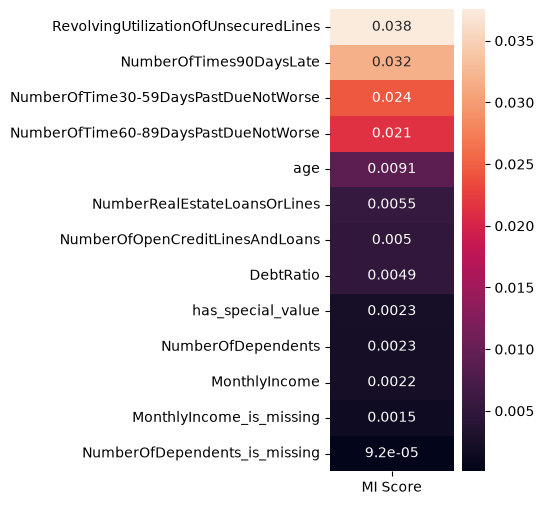

In [ ]:
# Display the first feature-relevance assessment.
create_mi()

Mutual information captures non-linear relationships that correlation alone would miss (relevant 
for tree-based models); correlation is more directly informative for the linear model. Comparing 
both — rather than relying on either alone — gives a fuller picture before engineering new features.

In [ ]:
# Calculate linear correlations between training features and the target.
def create_corr_matrix():
    # Work on a copy so the target is added without changing x_train.
    train_df = pd.DataFrame(x_train).copy()
    train_df["Target"] = y_train
    correlation_matrix = train_df.corr()

    # Extract and rank correlations with the target column.
    single_corr = correlation_matrix[["Target"]].sort_values(by="Target", ascending=False)
    # Visualize the sorted target correlations.
    plt.figure(figsize=(2, 6))  
    return sns.heatmap(data=single_corr, annot=True)


<Axes: >

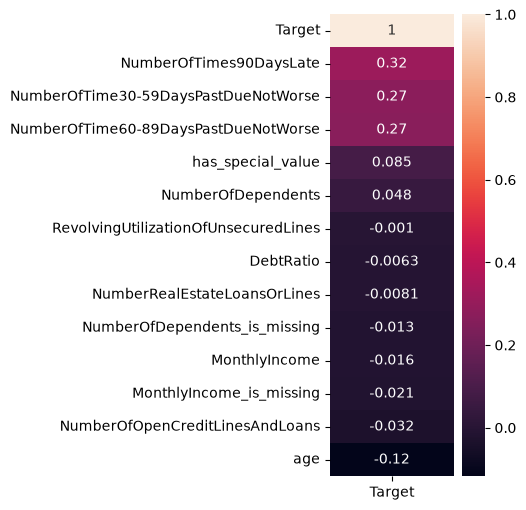

In [ ]:
# Display the first correlation-based relevance assessment.
create_corr_matrix()

`NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`, 
`NumberOfTime60-89DaysPastDueNotWorse`, `NumberOfDependents`, `age`, and 
`RevolvingUtilizationOfUnsecuredLines` show the strongest relevance to the target in both checks 
— these are the features prioritized for engineering below.

## Feature Engineering

New features are derived from the columns identified above as most relevant to the target.

In [ ]:
# Add domain-informed aggregate and ratio features.
def engineer_features(df):
    # Convert the dependent count into a simple presence indicator.
    df['has_dependent'] = (df['NumberOfDependents'] > 0).astype(int)
    # Aggregate the three late-payment counts into an overall severity measure.
    df['total_late_payments'] = df[late_cols].sum(axis=1)
    # Capture whether any late payment occurred at all.
    df['has_any_late_payment'] = (df[late_cols].sum(axis=1) > 0).astype(int)
    # Normalize income by household size while avoiding division by zero.
    df['income_per_dependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)
    return df

- `has_dependent` — simplifies `NumberOfDependents` into a binary signal, useful if the linear 
  model struggles to capture a non-linear relationship in the raw count.
- `total_late_payments` — aggregates the three "days past due" columns into a single severity 
  measure.
- `has_any_late_payment` — a coarser binary version of the above, in case the exact count matters 
  less than the mere presence of any late payment.
- `income_per_dependent` — combines income and household size, which individually showed weak 
  correlation with the target, but their ratio may be more informative.

In [ ]:
# Apply feature engineering consistently across the labeled data splits.
x_train = engineer_features(x_train)
x_cv = engineer_features(x_cv)
x_test = engineer_features(x_test)

## Outlier Handling for Discrete and Continuous Features

Based on the EDA, `NumberOfOpenCreditLinesAndLoans` and `NumberRealEstateLoansOrLines` are 
clipped at the 99th percentile (computed on `x_train`), and the three heavily right-skewed 
continuous features are log-transformed (`log1p`, to safely handle zero values).

In [ ]:
# Define feature groups for clipping and logarithmic transformation.
discrete_features =  ['NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines']
continuous_features = ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']

# Learn 99th-percentile clipping thresholds from the training set only.
clip_uppers = {}
for col in discrete_features:
    upper = x_train[col].quantile(0.99)
    clip_uppers[col] = upper

In [ ]:
# Apply training-derived clipping and log transformations to a dataset.
def normalize_data(df):
    # Cap rare extreme values in discrete features.
    for col in discrete_features:
        df[col] = df[col].clip(upper=clip_uppers[col])

    # Reduce right skew while preserving zero values with log1p.
    for feature in continuous_features:
        df[feature] = np.log1p(df[feature])

    return df

In [ ]:
# Apply clipping and log transformations to all labeled splits.
x_train = normalize_data(x_train)
x_cv = normalize_data(x_cv)
x_test = normalize_data(x_test)

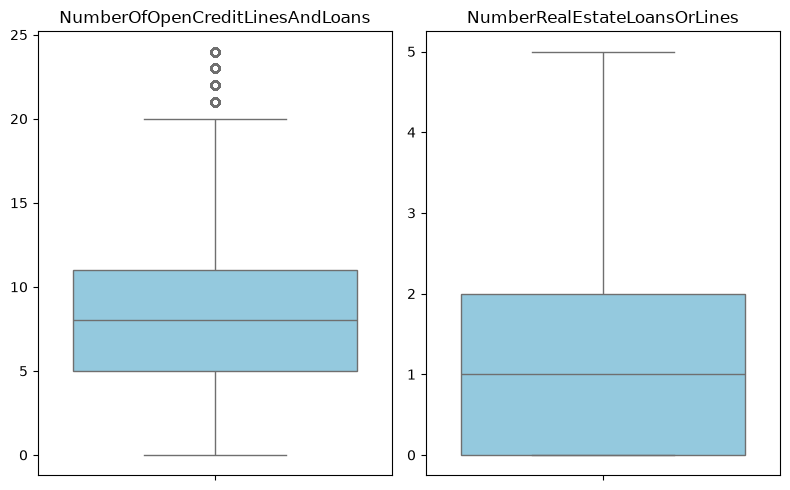

In [ ]:
# Inspect the discrete features after percentile clipping.
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes = axes.flatten()  

# Draw one boxplot for each clipped feature.
for i, col in enumerate(discrete_features):
    sns.boxplot(data=x_train, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('') 

# Arrange the plots and display them.
plt.tight_layout()
plt.show()

The extreme tail values in both discrete features are now capped, as intended.

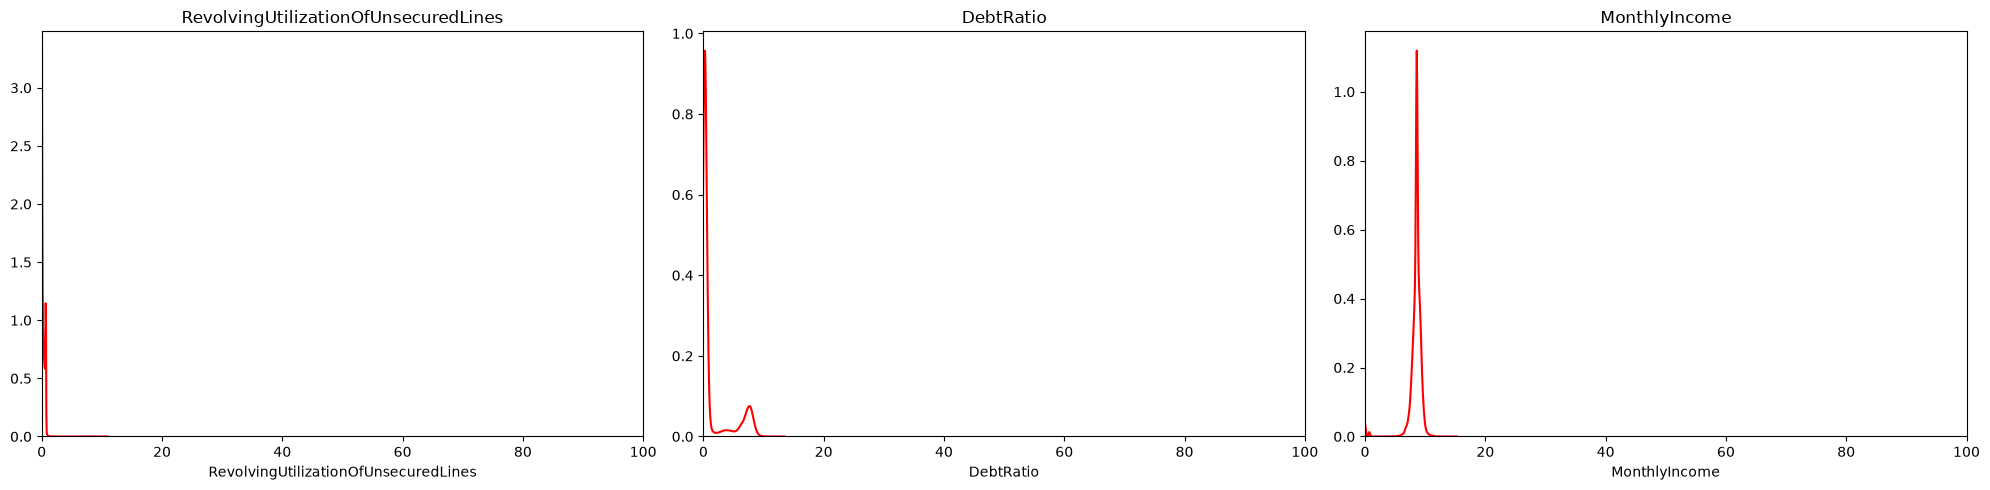

In [ ]:
# Inspect the continuous feature distributions after log transformation.
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes = axes.flatten()  

# Plot the transformed density for each continuous feature.
for i, col in enumerate(continuous_features):
    sns.kdeplot(data=x_train, x=col, ax=axes[i], color='red')
    axes[i].set_title(col)
    axes[i].set_ylabel('')

    # Use consistent display limits for the transformed values.
    if col == 'RevolvingUtilizationOfUnsecuredLines':
        axes[i].set_xlim(0, 100)  
    elif col == 'DebtRatio':
        axes[i].set_xlim(0, 100)  
    elif col == 'MonthlyIncome':
        axes[i].set_xlim(0, 100) 

# Arrange the plots and display them.
plt.tight_layout()
plt.show()

After the log transform, all three continuous features show a noticeably more compact, less 
skewed distribution — this benefits the linear model in particular, which is sensitive to extreme values.

## Age Encoding

`age` is bucketed into four life-stage groups. Since the categories have a natural order 
(young < middle < senior < elder), an ordinal encoding is created first — suitable for tree-based 
models, which split on thresholds and don't require one-hot encoding for ordered categories.

In [ ]:
# Review the age distribution before defining life-stage buckets.
x_train['age'].describe()

count    89634.000000
mean        52.323906
std         14.727100
min         21.000000
25%         41.000000
50%         52.000000
75%         63.000000
max        109.000000
Name: age, dtype: float64

In [ ]:
# Define ordered age intervals and labels for life-stage encoding.
bins = [-np.inf, 30, 45, 60, np.inf]
labels = ['young', 'middle', 'senior', 'elder']
# Map ordered age categories to numeric values for tree-based models.
age_order = {'young': 0, 'middle': 1, 'senior': 2, 'elder': 3}

# Create an ordered age representation for a dataset.
def create_age_bucket(df):
    df['age_bucket'] = pd.cut(df['age'], bins=bins, labels=labels)
    df['age_bucket_ordinal'] = df['age_bucket'].map(age_order)
    df.drop('age_bucket', axis=1, inplace=True) 
    return df

In [ ]:
# Add the ordinal age feature to all labeled splits.
x_train = create_age_bucket(x_train)
x_cv = create_age_bucket(x_cv)
x_test = create_age_bucket(x_test)

## Encoding for the Linear Model

Logistic Regression interprets numeric inputs as continuous quantities, so the ordinal age 
encoding would incorrectly imply equal "distance" between age groups. A separate, one-hot 
encoded version of the age feature is created specifically for the linear model and the neural 
network, while tree-based models keep the ordinal version.

In [ ]:
# Fit the one-hot encoder on the training age categories only.
OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
OH_encoder.fit(x_train[['age_bucket_ordinal']])

# Replace the ordinal age feature with one-hot columns for linear models.
def encode_age_for_linear(df):
    # Work on a copy so the tree-model feature set remains unchanged.
    df = df.copy()
    # Transform the ordinal age values into one-hot columns with matching indices.
    OH_col = pd.DataFrame(OH_encoder.transform(df[['age_bucket_ordinal']]), index=df.index, columns=OH_encoder.get_feature_names_out(['age_bucket_ordinal']))
    # Remove the ordinal representation and append the one-hot representation.
    num_df = df.drop('age_bucket_ordinal', axis=1)
    OH_df = pd.concat([num_df, OH_col], axis=1)
    return OH_df

In [ ]:
# Build one-hot encoded feature sets for the linear model and neural network.
x_train_for_lr = encode_age_for_linear(x_train)
x_cv_for_lr = encode_age_for_linear(x_cv)
x_test_for_lr = encode_age_for_linear(x_test)

# Preview the resulting linear-model feature matrix.
x_train_for_lr.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,...,NumberOfDependents_is_missing,has_special_value,has_dependent,total_late_payments,has_any_late_payment,income_per_dependent,age_bucket_ordinal_0,age_bucket_ordinal_1,age_bucket_ordinal_2,age_bucket_ordinal_3
10136,0.124067,36,0,0.379407,8.071219,8,0,2,0,1.0,...,0,0,1,0,0,1600.0,0.0,1.0,0.0,0.0
108359,0.282120,59,0,0.658395,8.006701,11,0,2,0,0.0,...,0,0,0,0,0,3000.0,0.0,0.0,1.0,0.0
82441,0.050473,52,0,0.203833,9.627998,16,0,1,0,2.0,...,0,0,1,0,0,5061.0,0.0,0.0,1.0,0.0
138179,0.087752,64,0,6.606650,8.597297,4,0,0,0,0.0,...,0,0,0,0,0,5416.0,0.0,0.0,0.0,1.0
117199,0.596838,21,0,2.564949,8.597297,1,0,0,0,0.0,...,1,0,0,0,0,5416.0,1.0,0.0,0.0,0.0


This creates two parallel feature sets from this point forward: `x_train`/`x_cv`/`x_test` 
(ordinal age, unscaled — for Decision Tree, Random Forest, XGBoost) and 
`x_train_for_lr`/`x_cv_for_lr`/`x_test_for_lr` (one-hot age — for Logistic Regression and the 
neural network).

In [ ]:
# Fit the scaler on training features only and save it for future inference.
scaler = StandardScaler()
scaler.fit(x_train_for_lr)
joblib.dump(scaler, '../models/scaler.joblib')

['../models/scaler.joblib']

`StandardScaler` is fit on `x_train_for_lr` only and applied to all three sets. Scaling is 
required for Logistic Regression and the neural network, since both treat features as 
weighted sums — unscaled features with larger numeric ranges would dominate the model 
regardless of their actual importance. Tree-based models are unaffected by feature scale and are 
trained on the unscaled `x_train`/`x_cv`/`x_test` instead.

In [ ]:
# Apply the training-fitted scaler to each labeled split.
x_train_scaled = pd.DataFrame(scaler.transform(x_train_for_lr), columns=x_train_for_lr.columns, index=x_train_for_lr.index)
x_cv_scaled = pd.DataFrame(scaler.transform(x_cv_for_lr), columns=x_cv_for_lr.columns, index=x_cv_for_lr.index)
x_test_scaled = pd.DataFrame(scaler.transform(x_test_for_lr), columns=x_test_for_lr.columns, index=x_test_for_lr.index)

## Feature Relevance Check — Round 2 (After Feature Engineering)

Mutual information and correlation are recomputed on the final `x_train` feature set — now 
including the engineered features, the "days past due" fix, and the log-transformed/clipped 
values — to confirm whether the engineered features actually carry signal, rather than relying 
on intuition alone.

<Axes: >

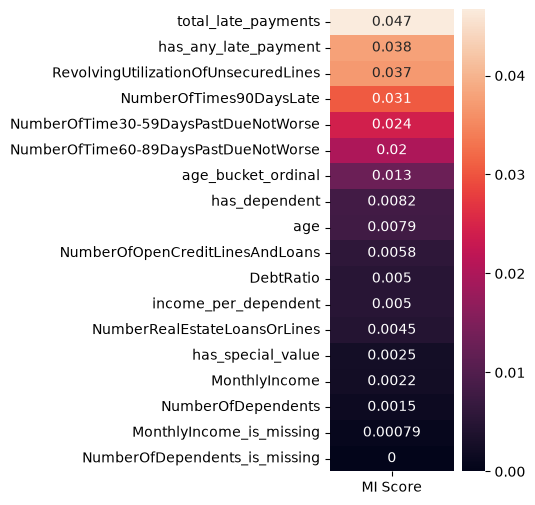

In [ ]:
# Recalculate mutual information after all feature-engineering transformations.
create_mi()

<Axes: >

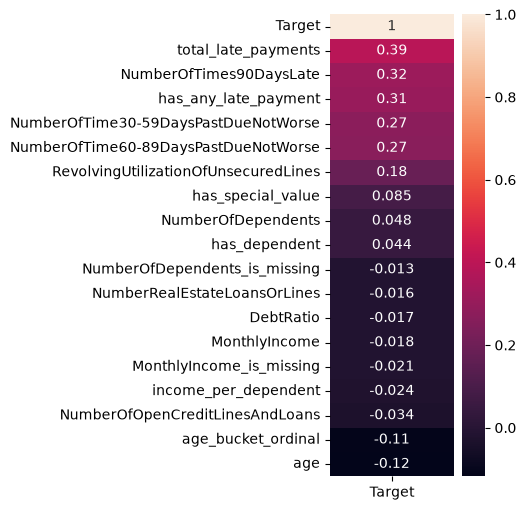

In [ ]:
# Recalculate target correlations on the final transformed feature set.
create_corr_matrix()

## Processing the External Test Set

The Kaggle test set (`cs-test.csv`) has no target labels and is used only for final submission, 
not for model selection. It goes through the exact same preprocessing steps as `x_train`/`x_cv`/
`x_test`, but using statistics (medians, clipping thresholds, scaler parameters) already fitted 
on `x_train` — nothing is recomputed on this file, to keep it consistent with how the model was trained.

In [ ]:
# Load the external Kaggle test set, which has no target labels.
test_data = pd.read_csv('../data/cs-test.csv')
# Preview the raw external test data.
test_data.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


In [ ]:
# Remove the row index and empty target column from the external test data.
test_data = test_data.drop(['Unnamed: 0', 'SeriousDlqin2yrs'], axis=1)
# Confirm the remaining input features.
test_data.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


`Unnamed: 0` and the empty `SeriousDlqin2yrs` column (present but unlabeled in this file) are dropped.

In [ ]:
# Apply the exact transformations learned from x_train to the external test data.
test_data = (test_data
    .pipe(fill_missings)
    .pipe(change_features)
    .pipe(engineer_features)
    .pipe(normalize_data)
    .pipe(create_age_bucket)
)

In [ ]:
# Create the one-hot encoded version required by the linear model.
test_data_for_lr = encode_age_for_linear(test_data)
# Preview the processed external test features.
test_data_for_lr.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,...,NumberOfDependents_is_missing,has_special_value,has_dependent,total_late_payments,has_any_late_payment,income_per_dependent,age_bucket_ordinal_0,age_bucket_ordinal_1,age_bucket_ordinal_2,age_bucket_ordinal_3
0,0.634203,43,0,0.163404,8.648397,4,0,0,0,0.0,...,0,0,0,0,0,5700.000000,0.0,1.0,0.0,0.0
1,0.380691,57,0,0.423460,9.120634,15,0,4,0,2.0,...,0,0,1,0,0,3047.000000,0.0,0.0,1.0,0.0
2,0.042365,59,0,0.523336,8.533854,12,0,1,0,2.0,...,0,0,1,0,0,1694.333333,0.0,0.0,1.0,0.0
3,0.247101,38,1,0.655425,8.071219,7,0,2,0,0.0,...,0,0,0,1,1,3200.000000,0.0,1.0,0.0,0.0
4,0.693147,27,0,0.019721,8.259976,4,0,0,0,1.0,...,0,0,1,0,0,1932.500000,1.0,0.0,0.0,0.0


In [ ]:
# Scale the external test features with the scaler fitted on x_train.
cs_test_scaled = pd.DataFrame(scaler.transform(test_data_for_lr), columns=test_data_for_lr.columns, index=test_data_for_lr.index)

## Saving Processed Data

All processed sets are saved to `data/processed/` so that `03_modeling.ipynb` can load them 
directly, without re-running this notebook. The fitted `scaler` is saved separately via `joblib`, 
since it will be needed to transform any new data consistently with the training set in the future.

In [ ]:
# Save unscaled tree-model features and target labels for downstream modeling.
x_train.to_csv('../data/processed/x_train.csv', index=False)
x_cv.to_csv('../data/processed/x_cv.csv', index=False)
x_test.to_csv('../data/processed/x_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_cv.to_csv('../data/processed/y_cv.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)
test_data.to_csv('../data/processed/cs_test_processed.csv', index=False)

In [ ]:
# Save scaled linear-model features for downstream modeling and submission.
x_train_scaled.to_csv('../data/processed/x_train_scaled.csv', index=False)
x_cv_scaled.to_csv('../data/processed/x_cv_scaled.csv', index=False)
x_test_scaled.to_csv('../data/processed/x_test_scaled.csv', index=False)
cs_test_scaled.to_csv('../data/processed/cs_test_scaled.csv', index=False)